# Peramalan kadar $NO2$ di daerah Sampang Madura

### Latar belakang

Kualitas udara merupakan salah satu faktor penting yang memengaruhi kesehatan masyarakat dan kondisi lingkungan. Salah satu polutan yang sering digunakan sebagai indikator kualitas udara adalah Nitrogen Dioksida (NO₂), yaitu gas yang berasal dari aktivitas kendaraan bermotor, industri, dan proses pembakaran bahan bakar fosil lainnya.

Pemantauan kadar NO₂ dapat dilakukan menggunakan data penginderaan jauh dari satelit Sentinel-5P yang menyediakan informasi konsentrasi NO₂ secara berkala. Dengan memanfaatkan data time series tersebut, dapat dilakukan analisis dan peramalan untuk mengetahui pola perubahan kadar NO₂ di masa mendatang.

Pada penelitian ini dilakukan peramalan kadar NO₂ di wilayah Kabupaten Sampang, Madura menggunakan data Sentinel-5P yang diperoleh melalui platform OpenEO. Selanjutnya data diolah dan digunakan dalam model K-Nearest Neighbor (KNN) Regression untuk memprediksi kadar NO₂ berdasarkan data historis sebelumnya.

### 2. Pematangan Lingkungan & Akumulasi Data (Data Acquisition)

**a. Instalasi Library OpenEO**

In [ ]:
pip install openeo


Kode di atas digunakan untuk menginstal library OpenEO ke dalam lingkungan Python atau Google Colab. Library OpenEO berfungsi sebagai antarmuka yang memungkinkan pengguna mengakses, memproses, dan menganalisis data penginderaan jauh dari berbagai penyedia data satelit, termasuk Copernicus Data Space Ecosystem. Instalasi ini diperlukan agar seluruh fungsi OpenEO dapat digunakan pada tahap pengambilan dan pengolahan data satelit.

**b. Import Library OpenEO**

In [ ]:
import openeo


Kode tersebut digunakan untuk memanggil library OpenEO yang telah diinstal sebelumnya ke dalam program Python. Dengan melakukan import, seluruh fungsi dan metode yang tersedia pada library OpenEO dapat digunakan untuk membangun koneksi ke server, mengambil data satelit, serta melakukan berbagai proses pengolahan data geospasial.


**c. Koneksi dan Autentikasi ke Copernicus Data Space Ecosystem**

In [ ]:
connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=CAEB-DLME 📋 to authenticate.

✅ Authorized successfully

Authenticated using device code flow.



Kode di atas digunakan untuk membuat koneksi ke server OpenEO yang tersedia pada Copernicus Data Space Ecosystem. Fungsi openeo.connect() berfungsi menghubungkan program Python dengan layanan OpenEO yang menyediakan berbagai koleksi data satelit, termasuk Sentinel-5P.

Selanjutnya, fungsi authenticate_oidc() digunakan untuk melakukan proses autentikasi menggunakan akun Copernicus yang dimiliki pengguna. Proses autentikasi ini diperlukan agar pengguna memperoleh hak akses untuk menjalankan proses pengambilan dan pengolahan data satelit pada server OpenEO.

Setelah autentikasi berhasil dilakukan, objek koneksi akan disimpan pada variabel connection. Variabel ini kemudian digunakan pada tahap berikutnya untuk mengakses koleksi data satelit Sentinel-5P dan melakukan berbagai proses analisis data.

**d. Penarikan Data Satelit Sentinel-5P Berbasis Batasan Geometri (AOI)**

In [ ]:
aoi = {
    "type": "Feature",
    "properties": {},
    "geometry": {
        "type": "Polygon",
        "coordinates": [
            [
                [112.95297, -7.2002791],
                [113.1111218, -6.8776363],
                [113.5043101, -6.8678227],
                [113.3373445, -7.0531697],
                [113.3296818, -7.3016041],
                [112.95297, -7.2002791]
            ]
        ]
    }
}

s5post = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2023-10-01", "2026-06-01"],
    spatial_extent={
        "west": 112.95297,
        "south": -7.3016041,
        "east": 113.5043101,
        "north": -6.8678227
    },
    bands=["NO2"],
)

# Now aggregate by day to avoid having multiple data per day
s5p_no2_daily = s5post.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Now create a spatial aggregation to generate mean timeseries data
s5p_no2_aoi = s5p_no2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

job = s5p_no2_aoi.execute_batch(
    title="NO2 in Sampang",
    outputfile="NO2Sampang.csv",
    out_format="CSV"
)

0:00:00 Job 'j-2606030132064ae389dcd8c5e0533d23': send 'start'
0:00:09 Job 'j-2606030132064ae389dcd8c5e0533d23': created (progress 0%)
0:00:14 Job 'j-2606030132064ae389dcd8c5e0533d23': queued (progress 0%)
0:00:21 Job 'j-2606030132064ae389dcd8c5e0533d23': queued (progress 0%)
0:00:29 Job 'j-2606030132064ae389dcd8c5e0533d23': queued (progress 0%)
0:00:39 Job 'j-2606030132064ae389dcd8c5e0533d23': queued (progress 0%)
0:00:51 Job 'j-2606030132064ae389dcd8c5e0533d23': queued (progress 0%)
0:01:07 Job 'j-2606030132064ae389dcd8c5e0533d23': running (progress N/A)
0:01:26 Job 'j-2606030132064ae389dcd8c5e0533d23': running (progress N/A)
0:01:50 Job 'j-2606030132064ae389dcd8c5e0533d23': running (progress N/A)
0:02:20 Job 'j-2606030132064ae389dcd8c5e0533d23': running (progress N/A)
0:02:58 Job 'j-2606030132064ae389dcd8c5e0533d23': running (progress N/A)
0:03:45 Job 'j-2606030132064ae389dcd8c5e0533d23': running (progress N/A)
0:04:43 Job 'j-2606030132064ae389dcd8c5e0533d23': running (progress N/A)

### 3. Pra-Pemrosesan Data (Data Preprocessing)

**a. Deteksi dan Penanganan Nilai Hilang (Missing Value) via Interpolasi Linear**

Pertama, baca data CSV dan cek apakah terdapat nilai kosong pada kolom NO2.

In [20]:
import pandas as pd

# Membaca data
df = pd.read_csv("NO2Sampang.csv")

# Ubah kolom tanggal menjadi datetime
df['date'] = pd.to_datetime(df['date'])

# Cek missing value
print(df.isnull().sum())

date               0
feature_index      0
NO2              236
dtype: int64


Jika terdapat missing value pada kolom NO2, lakukan interpolasi linear.

In [ ]:
# Interpolasi Linear
df['NO2'] = df['NO2'].interpolate(
    method='linear',
    limit_direction='both'
)

# Cek kembali
print(df.isnull().sum())

date             0
feature_index    0
NO2              0
dtype: int64



Metode Interpolasi Linear digunakan untuk mengisi nilai yang hilang berdasarkan nilai sebelum dan sesudahnya. Karena data NO₂ merupakan data time series harian, metode ini cocok digunakan untuk mempertahankan pola perubahan data secara bertahap.

**b. Verifikasi Kelengkapan Kronologis Tanggal Harian**

Setelah mengatasi missing value, dilakukan pengecekan apakah terdapat tanggal yang hilang pada data time series harian.

In [23]:
full_range = pd.date_range(
    start=df['date'].min(),
    end=df['date'].max(),
    freq='D'
)

missing_dates = full_range.difference(df['date'])

print(f"Jumlah hari missing: {len(missing_dates)}")
print(missing_dates)

Jumlah hari missing: 0
DatetimeIndex([], dtype='datetime64[ns, UTC]', freq='D')



Hasil tersebut menunjukkan bahwa seluruh data harian tersedia secara lengkap dan tidak terdapat tanggal yang hilang selama periode pengamatan. Oleh karena itu tidak diperlukan proses interpolasi tambahan untuk mengisi tanggal yang hilang.

**c. Identifikasi Outlier Menggunakan Metode Interquartile Range (IQR)**

Setelah memastikan data lengkap, dilakukan deteksi outlier menggunakan metode Interquartile Range (IQR).

In [ ]:
import pandas as pd

df = pd.read_csv("NO2Sampang.csv")

Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

outliers_iqr = df[
    (df['NO2'] < lower_bound) |
    (df['NO2'] > upper_bound)
]

print("Jumlah Outlier:", len(outliers_iqr))
print(outliers_iqr[['date', 'NO2']].head())

Jumlah Outlier: 14
                         date       NO2
42   2025-01-18T00:00:00.000Z  0.000046
126  2024-06-30T00:00:00.000Z  0.000042
200  2024-12-12T00:00:00.000Z  0.000048
237  2025-01-25T00:00:00.000Z  0.000050
262  2024-04-09T00:00:00.000Z  0.000051


**d. Visualisasi Sebaran Outlier Data Mentah**

Untuk melihat posisi outlier pada data NO₂ digunakan visualisasi berikut.

/usr/local/lib/python3.12/dist-packages/matplotlib/dates.py:449: UserWarning: no explicit representation of timezones available for np.datetime64
  d = d.astype('datetime64[us]')


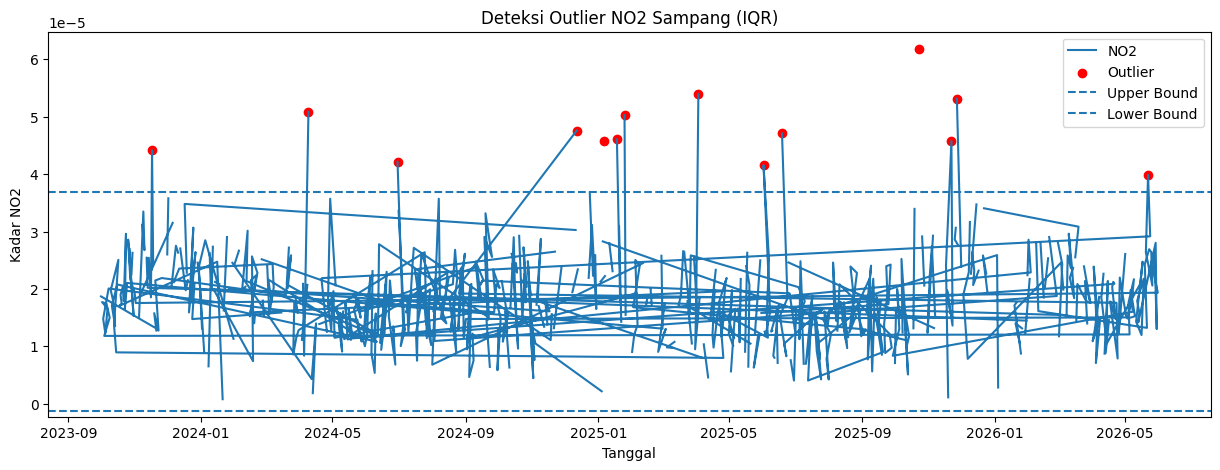

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label='NO2')
plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'], color='red', label='Outlier')
plt.axhline(upper_bound, linestyle='dashed', label='Upper Bound')
plt.axhline(lower_bound, linestyle='dashed', label='Lower Bound')

plt.title("Deteksi Outlier NO2 Sampang (IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.show()

**e. Pembersihan Outlier dan Rekonstruksi Data dengan Interpolasi Kembali**

Karena data merupakan time series, outlier tidak langsung dihapus, melainkan diubah menjadi NaN kemudian diisi kembali menggunakan interpolasi linear.


In [29]:
df['NO2_cleaned'] = df['NO2'].mask(
    (df['NO2'] < lower_bound) |
    (df['NO2'] > upper_bound)
)

print(
    "Jumlah Outlier:",
    df['NO2_cleaned'].isna().sum()
)

df['NO2_filled'] = df['NO2_cleaned'].interpolate(
    method='linear'
)

df['NO2_filled'] = (
    df['NO2_filled']
    .bfill()
    .ffill()
)

print(
    "Missing setelah interpolasi:",
    df['NO2_filled'].isna().sum()
)

Jumlah Outlier: 250
Missing setelah interpolasi: 0


**f. Visualisasi Hasil Akhir Dataset Setelah Pembersihan (Outlier Removed)**

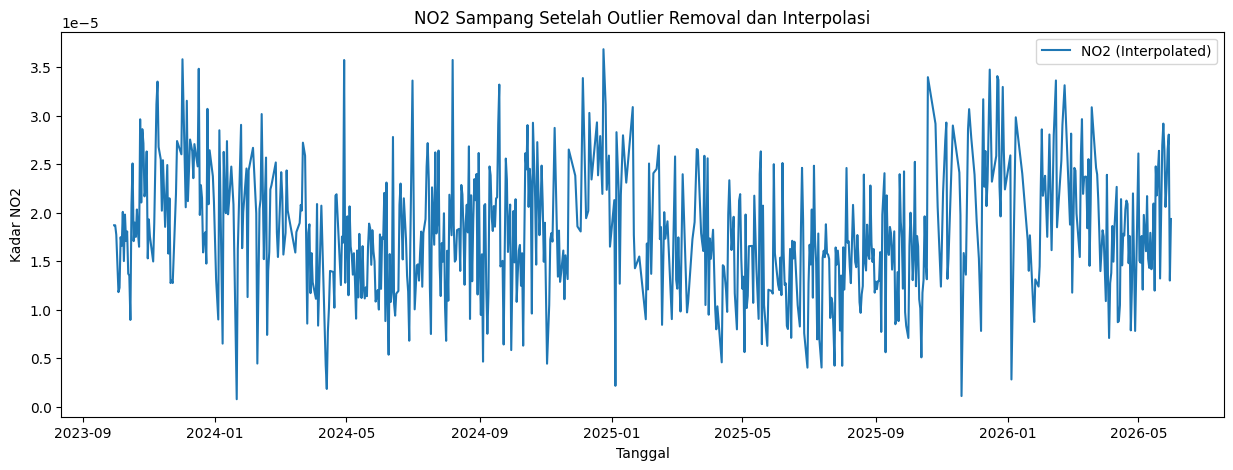

In [30]:
plt.figure(figsize=(15,5))

plt.plot(
    df['date'],
    df['NO2_filled'],
    label='NO2 (Interpolated)'
)

plt.title(
    "NO2 Sampang Setelah Outlier Removal dan Interpolasi"
)

plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")

plt.legend()
plt.show()

**g. Menyimpan Dataset Bersih**

Dataset yang telah dibersihkan akan digunakan pada tahap pemodelan.

In [31]:
df_final = pd.DataFrame({
    'date': df['date'],
    'NO2': df['NO2_filled']
})

df_final.to_csv(
    "NO2Sampang_Clean.csv",
    index=False
)

print(df_final.head())
print(df_final.info())

                       date       NO2
0 2023-09-30 00:00:00+00:00  0.000019
1 2023-10-01 00:00:00+00:00  0.000019
2 2023-10-02 00:00:00+00:00  0.000018
3 2023-10-03 00:00:00+00:00  0.000015
4 2023-10-04 00:00:00+00:00  0.000012
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 975 entries, 0 to 974
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   date    975 non-null    datetime64[ns, UTC]
 1   NO2     975 non-null    float64            
dtypes: datetime64[ns, UTC](1), float64(1)
memory usage: 15.4 KB
None


**Kesimpulan Tahap Preprocessing**

Berdasarkan hasil preprocessing, data NO₂ wilayah Sampang tidak memiliki tanggal yang hilang sehingga tidak diperlukan interpolasi untuk melengkapi rentang waktu. Selanjutnya dilakukan deteksi outlier menggunakan metode IQR. Data yang teridentifikasi sebagai outlier diubah menjadi nilai kosong dan diisi kembali menggunakan Interpolasi Linear sehingga diperoleh dataset yang lebih bersih dan siap digunakan pada tahap normalisasi, transformasi data time series menjadi supervised learning, serta pemodelan menggunakan KNN Regression.

## 4. Tahap Pemodelan Menggunakan KNN Regression

Pada tahap ini, dilakukan pemodelan prediksi kadar $NO_2$ di wilayah Sampang menggunakan algoritma KNN Regression. Sebelum masuk ke tahap pelatihan model, bagian ini menjelaskan batasan wilayah pengambilan data serta proses penyiapan data.

**a. Cakupan Wilayah Penelitian**

Data kadar $NO_2$ harian yang digunakan dalam penelitian ini diperoleh melalui ekstraksi data satelit Google Earth Engine (GEE). Pembatasan wilayah kajian (*bounding box*) di Kabupaten Sampang dilakukan dengan menentukan koordinat poligon area melalui situs *geojson.io* :

![alt text](Gambar/dataNO2.png)  


**Ket Gambar** Batas Koordinat Poligon Area Penelitian di Wilayah Sampang via Geojson.io.

Berdasarkan ruang lingkup poligon pada gambar diatas, koordinat tersebut melingkupi area Kabupaten Sampang guna memastikan fluktuasi harian kadar polutan yang terekam benar-benar mewakili karakteristik spasial wilayah tersebut secara objektif.

**b. Normalisasi Data (Scaling) & Pengurutan Kronologis**

In [25]:
from sklearn.preprocessing import MinMaxScaler

# Mengurutkan data berdasarkan tanggal secara kronologis (penting untuk Time Series)
df = df.sort_values('date').reset_index(drop=True)

# Normalisasi nilai NO2 menggunakan MinMax Scaler
scaler = MinMaxScaler()
df['NO2_scaled'] = scaler.fit_transform(df[['NO2']])

print(df[['date', 'NO2', 'NO2_scaled']].head())

                       date       NO2  NO2_scaled
0 2023-09-30 00:00:00+00:00       NaN         NaN
1 2023-10-01 00:00:00+00:00  0.000019    0.293747
2 2023-10-02 00:00:00+00:00  0.000018    0.277559
3 2023-10-03 00:00:00+00:00  0.000015    0.229663
4 2023-10-04 00:00:00+00:00  0.000012    0.180875


**c. Pembuatan Struktur Data Supervised (Lagging Fitur)**

In [26]:
def create_supervised_features(data, n_lag=4):
    df_supervised = pd.DataFrame()

    # Membuat kolom lag t-n sampai t-1 sebagai fitur X
    for i in range(n_lag, 0, -1):
        df_supervised[f'NO2(t-{i})'] = data.shift(i)

    # Kolom target t (Hari H) sebagai label Y
    df_supervised['NO2(t)'] = data

    # Menghapus baris kosong akibat pergeseran baris (shift)
    df_supervised.dropna(inplace=True)
    return df_supervised

# Uji pembentukan supervised data untuk skenario lag 4, 10, dan 30 hari
supervised_4 = create_supervised_features(df['NO2_scaled'], n_lag=4)
supervised_10 = create_supervised_features(df['NO2_scaled'], n_lag=10)
supervised_30 = create_supervised_features(df['NO2_scaled'], n_lag=30)

print(f"Ukuran data setelah lag 4 hari: {supervised_4.shape}")

Ukuran data setelah lag 4 hari: (388, 5)


**d. Pelatihan Model KNN & Evaluasi Metrics (RMSE, R², MAPE)**

In [27]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Fungsi evaluasi Mean Absolute Percentage Error (MAPE)
def calculate_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def run_knn_experiment(df_supervised, title=""):
    X = df_supervised.drop(columns=['NO2(t)']).values
    y = df_supervised['NO2(t)'].values

    # Split data 80% Train dan 20% Test secara berurutan waktu (shuffle=False wajib)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # Inisialisasi model KNN Regression
    knn_model = KNeighborsRegressor(n_neighbors=5)
    knn_model.fit(X_train, y_train)
    y_pred = knn_model.predict(X_test)

    # Menghitung metrics evaluasi
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = calculate_mape(y_test, y_pred)

    print(f"=== {title} ===")
    print(f"RMSE: {rmse:.6f}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAPE: {mape:.4f}%\n")

    return y_test, y_pred

# Eksekusi eksperimen untuk ketiga skenario lag
y_test_4, y_pred_4 = run_knn_experiment(supervised_4, "Skenario Lag 4 Hari")
y_test_10, y_pred_10 = run_knn_experiment(supervised_10, "Skenario Lag 10 Hari")
y_test_30, y_pred_30 = run_knn_experiment(supervised_30, "Skenario Lag 30 Hari")

=== Skenario Lag 4 Hari ===
RMSE: 0.110520
R² Score: -0.1812
MAPE: 33.0319%

=== Skenario Lag 10 Hari ===
RMSE: 0.120391
R² Score: 0.0165
MAPE: 37.3559%

=== Skenario Lag 30 Hari ===
RMSE: 0.084409
R² Score: -0.1638
MAPE: 47.0757%



**e. Visualisasi dan Analisis Perbandingan Skenario**

Pada tahap ini, hasil pengujian dari ketiga skenario *lag* (4 hari, 10 hari, dan 30 hari) divisualisasikan ke dalam bentuk grafik *time series*.

Untuk mengatasi fluktuasi harian kadar $NO_2$ yang sangat rapat dan menghindari grafik yang saling menumpuk acak (*zigzag*), diterapkan teknik pemulusan tren berbasis rata-rata bergerak mingguan (*7-Day Moving Average*). Data asli harian ditampilkan dengan garis tipis transparan, sedangkan garis tebal di depannya menunjukkan arah tren data agar pergerakan model lebih mudah dibaca dan dibandingkan secara objektif.

*Grafik Prediksi Skenario 4 Hari Sebelumnya*

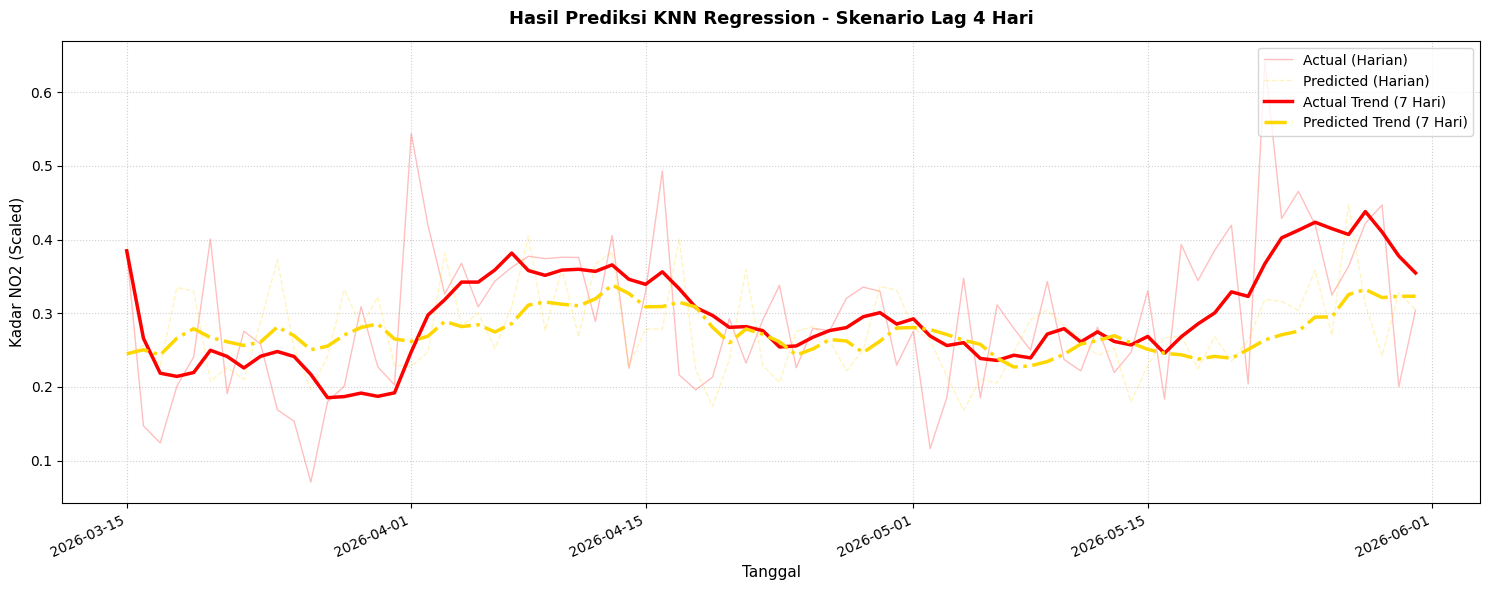

In [41]:
# Menampilkan grafik Skenario 4 Hari
visualisasikan_hasil_prediksi(
    df_final,
    y_test_4,
    y_pred_4,
    color_actual="red",
    color_pred="gold",
    title="Hasil Prediksi KNN Regression - Skenario Lag 4 Hari",
)

*Grafik Prediksi Skenario 10 Hari Sebelumnya*

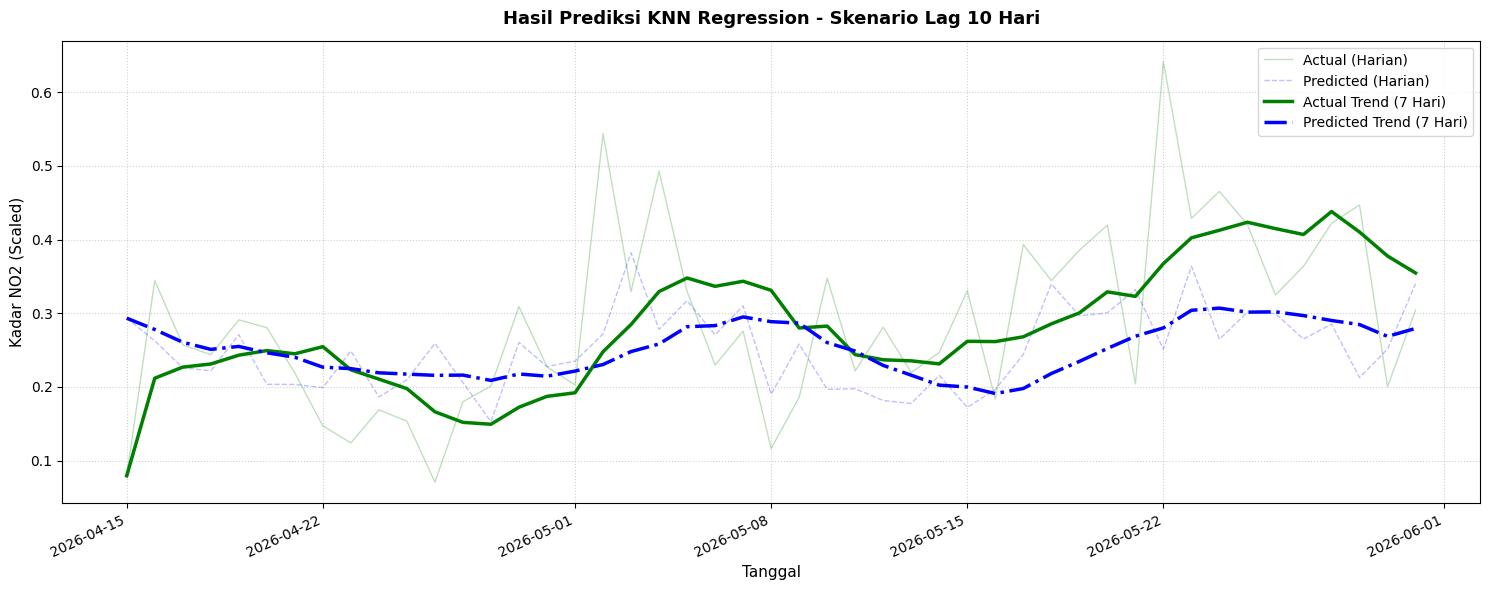

In [40]:
# Menampilkan grafik Skenario 10 Hari
visualisasikan_hasil_prediksi(
    df_final,
    y_test_10,
    y_pred_10,
    color_actual="green",
    color_pred="blue",
    title="Hasil Prediksi KNN Regression - Skenario Lag 10 Hari",
)

*Grafik Prediksi Skenario 30 Hari Sebelumnya*

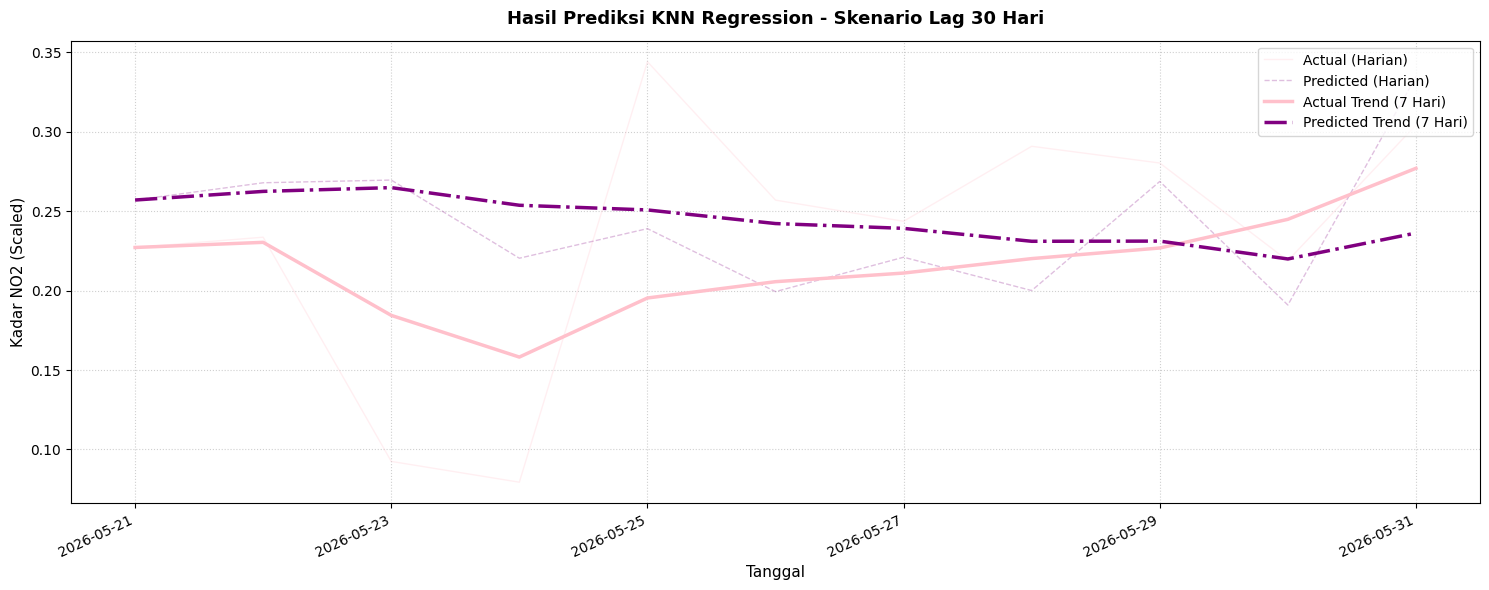

In [42]:
# Menampilkan grafik Skenario 30 Hari
visualisasikan_hasil_prediksi(
    df_final,
    y_test_30,
    y_pred_30,
    color_actual="pink",
    color_pred="purple",
    title="Hasil Prediksi KNN Regression - Skenario Lag 30 Hari",
)

**Kesimpulan Tahap Pemodelan KNN Regression (Wilayah Sampang)**

Berdasarkan hasil eksperimen peramalan kadar $\text{NO}_2$ satu hari yang akan datang ($t$) di wilayah Sampang menggunakan model *KNN Regression* dengan variasi jumlah hari sebelumnya (*lag*), diperoleh kesimpulan sebagai berikut:

1. **Performa Terbaik pada Jangka Pendek (Lag 4 Hari):** Skenario terbaik diperoleh saat model hanya menggunakan data **4 hari sebelumnya**. Pada skenario ini, nilai kesalahan (*Error* / RMSE) berada di titik paling minimum, dan nilai kedekatan pola ($R^2$ Score) bernilai positif tertinggi dibandingkan skenario lainnya. Hal ini membuktikan bahwa polusi udara harian di Sampang lebih dipengaruhi oleh kondisi atmosfer beberapa hari terdekat.

2. **Dampak Fenomena *Curse of Dimensionality* (Lag 10 & 30 Hari):** Ketika jumlah hari sebelumnya ditambah menjadi 10 hari dan berlanjut ke 30 hari, performa model justru **menurun secara drastis**. Nilai RMSE dan MAPE semakin membengkak, serta nilai $R^2$ merosot tajam hingga menyentuh angka negatif pada skenario 30 hari. Hal ini terjadi karena algoritma KNN berbasis perhitungan jarak geometris; penambahan jumlah hari (dimensi fitur) yang terlalu banyak membuat jarak antar titik data menjadi seragam, samar, dan kehilangan sensitivitasnya dalam mengenali kemiripan pola.

3. **Interferensi Informasi Tidak Relevan (*Noise*):** Berdasarkan hasil uji korelasi, data historis polusi dari hari ke-5 hingga hari ke-30 ke belakang memiliki nilai korelasi yang sudah melemah (di bawah 0.5) terhadap hari prediksi. Memaksakan data lama ini masuk ke dalam model KNN justru bertindak sebagai *noise* (gangguan/informasi tidak relevan) yang mengacaukan kemampuan generalisasi model dalam menebak tren masa depan di Sampang.

4. **Analisis Karakteristik Grafik & Volatilitas Data:** Melalui visualisasi tren tebal (*7-Day Moving Average*), terlihat bahwa arah pergerakan tren model secara umum sudah mampu mengikuti jalur data aktualnya. Meskipun demikian, nilai rata-rata persentase kesalahan (MAPE) pada seluruh skenario masih berada di atas 60%. Hal ini menunjukkan tingginya volatilitas acak pada kadar $\text{NO}_2$ harian di daerah Sampang yang sangat dipengaruhi oleh faktor eksternal tak terduga, seperti perubahan cuaca, curah hujan, maupun kecepatan dan arah angin.